# Dog Breed Classification — 120-Class CNN (Transfer Learning with MobileNetV2)

## Project Overview
This notebook builds an image classifier that identifies a dog's breed from a photograph, across **120 different breeds**, using the Stanford Dogs-style dataset. The approach uses **transfer learning**: a MobileNetV2 backbone pretrained on ImageNet is used as a frozen feature extractor, with a small custom classification head trained on top for this specific 120-class problem.

## Workflow
1. **Data Loading & Exploration** — mount storage, extract the dataset, validate folder structure, and inspect class balance, corrupted files, and image dimensions.
2. **Label Encoding & Splitting** — build a master image/label table, encode breeds as integers, and create stratified train/validation/test splits.
3. **`tf.data` Pipeline** — efficient on-the-fly image loading, resizing, shuffling, batching, and data augmentation.
4. **Model Architecture** — MobileNetV2 transfer learning with a custom classification head.
5. **Training** — with early stopping on validation loss.
6. **Evaluation** — test-set accuracy, per-class precision/recall/F1, confusion matrix, and misclassification analysis.
7. **Inference** — end-to-end prediction function tested on new, unseen images.

## Environment Setup
Core libraries: NumPy/Pandas for tabular data handling, Matplotlib/Seaborn for visualization, PIL for image I/O, TensorFlow/Keras for the model itself, and scikit-learn for the train/test split and evaluation metrics.


In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import tensorflow as tf
from tensorflow.keras import layers, models

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 1. Data Loading

The dataset is stored as a zip archive on Google Drive. The notebook runs on Google Colab, so Drive is mounted first to make the archive accessible to the runtime, and the archive is then extracted to local Colab storage for fast disk access during training.


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
zip_path = "/content/drive/MyDrive/dog-breed-120.zip"

In [5]:
import zipfile
import os

extract_path = "/content/dog_breed_dataset"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")
print("Location:", extract_path)

Dataset extracted successfully!
Location: /content/dog_breed_dataset


### 1.1 Verify Extracted Dataset Structure

After extracting the dataset archive, the first step is to confirm that the extraction succeeded and to inspect what is actually inside the target folder. This is a basic but important sanity check before any processing begins — if the folder structure is wrong, every downstream step (counting, splitting, loading) will silently work on the wrong data.


In [6]:
dataset_dir = "/content/dog_breed_dataset/Dogs class"
classes = sorted(os.listdir(dataset_dir))

print("Number of classes:", len(classes))
print("\nFirst 10 classes:")
print(classes[:10])

Number of classes: 122

First 10 classes:
['Untitled Folder', 'description.txt', 'n02085620-Chihuahua', 'n02085782-Japanese_spaniel', 'n02085936-Maltese_dog', 'n02086079-Pekinese', 'n02086240-Shih-Tzu', 'n02086646-Blenheim_spaniel', 'n02086910-papillon', 'n02087046-toy_terrier']


### 1.2 Filter Valid Class Folders and Count Images per Breed

The raw directory listing above shows **122** entries, not the expected 120 dog breeds. A closer look at the first few entries reveals two non-class items — `Untitled Folder` and `description.txt` — mixed in with the actual breed folders.

This cell cleans that up by:
- Keeping only entries that are **directories** (folders), which drops `description.txt`.
- Keeping only folders that contain **at least one image file** (`.jpg`, `.jpeg`, `.png`, `.bmp`, `.webp`), which drops the empty `Untitled Folder`.
- Counting the number of images inside each valid breed folder and storing it in a `class_counts_df` DataFrame for later analysis.

This guarantees that every downstream step operates on genuine breed classes only.


In [7]:
image_extensions = (".jpg", ".jpeg", ".png", ".bmp", ".webp")

# Get only folders containing images
classes = []

for cls in os.listdir(dataset_dir):
    class_path = os.path.join(dataset_dir, cls)

    # Check if it is a folder
    if os.path.isdir(class_path):

        # Check if folder contains at least one image
        has_image = any(
            file.lower().endswith(image_extensions)
            for file in os.listdir(class_path)
        )

        if has_image:
            classes.append(cls)

# Sort classes
classes = sorted(classes)

print("Number of valid classes:", len(classes))
print("First 10 classes:", classes[:10])


# Count images in each valid class
class_counts = {}

for cls in classes:
    class_path = os.path.join(dataset_dir, cls)

    count = sum(
        1
        for file in os.listdir(class_path)
        if file.lower().endswith(image_extensions)
    )

    class_counts[cls] = count


# Create DataFrame
class_counts_df = pd.DataFrame(
    list(class_counts.items()),
    columns=["Breed", "Image_Count"]
)

class_counts_df.head()

Number of valid classes: 120
First 10 classes: ['n02085620-Chihuahua', 'n02085782-Japanese_spaniel', 'n02085936-Maltese_dog', 'n02086079-Pekinese', 'n02086240-Shih-Tzu', 'n02086646-Blenheim_spaniel', 'n02086910-papillon', 'n02087046-toy_terrier', 'n02087394-Rhodesian_ridgeback', 'n02088094-Afghan_hound']


,Breed,Image_Count
0,n02085620-Chihuahua,152
1,n02085782-Japanese_spaniel,185
2,n02085936-Maltese_dog,252
3,n02086079-Pekinese,149
4,n02086240-Shih-Tzu,214


### 1.3 Dataset-Level Summary Statistics

With per-breed image counts available, this cell summarizes the dataset at a glance: total image count, number of breeds, and the minimum/maximum/average images per breed. These numbers are used to judge whether the dataset is large enough for deep learning and whether the classes are reasonably balanced (a large imbalance would require class weighting or resampling).


In [8]:
print("Total images:", class_counts_df["Image_Count"].sum())
print("Number of breeds:", len(class_counts_df))
print("Minimum images:", class_counts_df["Image_Count"].min())
print("Maximum images:", class_counts_df["Image_Count"].max())
print("Average images:", class_counts_df["Image_Count"].mean())

Total images: 20580
Number of breeds: 120
Minimum images: 148
Maximum images: 252
Average images: 171.5


**Observation:** The cleaned dataset contains **20,580 images across 120 breeds**, averaging **171.5 images per breed**, with the smallest class holding **148** images and the largest **252**. This is a solid, close-to-balanced dataset size for transfer learning.


### 1.4 Corrupted Image Check

Real-world image datasets scraped or bundled from external sources often contain a few truncated or unreadable files. Before training, every image in every class folder is opened with PIL to confirm it can be read without raising an error. Any file that fails to open is logged so it can be excluded from training — silently letting a corrupted file into the pipeline would crash training partway through an epoch, wasting compute time.


In [9]:
corrupted_images = []

for cls in classes:
    class_path = os.path.join(dataset_dir, cls)

    for image_name in os.listdir(class_path):

        if not image_name.lower().endswith(image_extensions):
            continue

        image_path = os.path.join(class_path, image_name)

        try:
            with Image.open(image_path) as img:
                img.verify()

        except Exception:
            corrupted_images.append(image_path)

print("Corrupted images:", len(corrupted_images))

if corrupted_images:
    print("\nExamples:")
    for path in corrupted_images[:10]:
        print(path)

Corrupted images: 0


**Observation:** No corrupted images were found (**0** unreadable files) across the entire dataset, so no images need to be excluded before building the training pipeline.


### 1.5 Class Distribution Visualization

A bar chart of image count per breed makes it easy to spot severe class imbalance, which the summary statistics alone can hide. If one or two breeds had drastically fewer images than the rest, the model would need class weighting or oversampling to avoid being biased toward the majority classes.


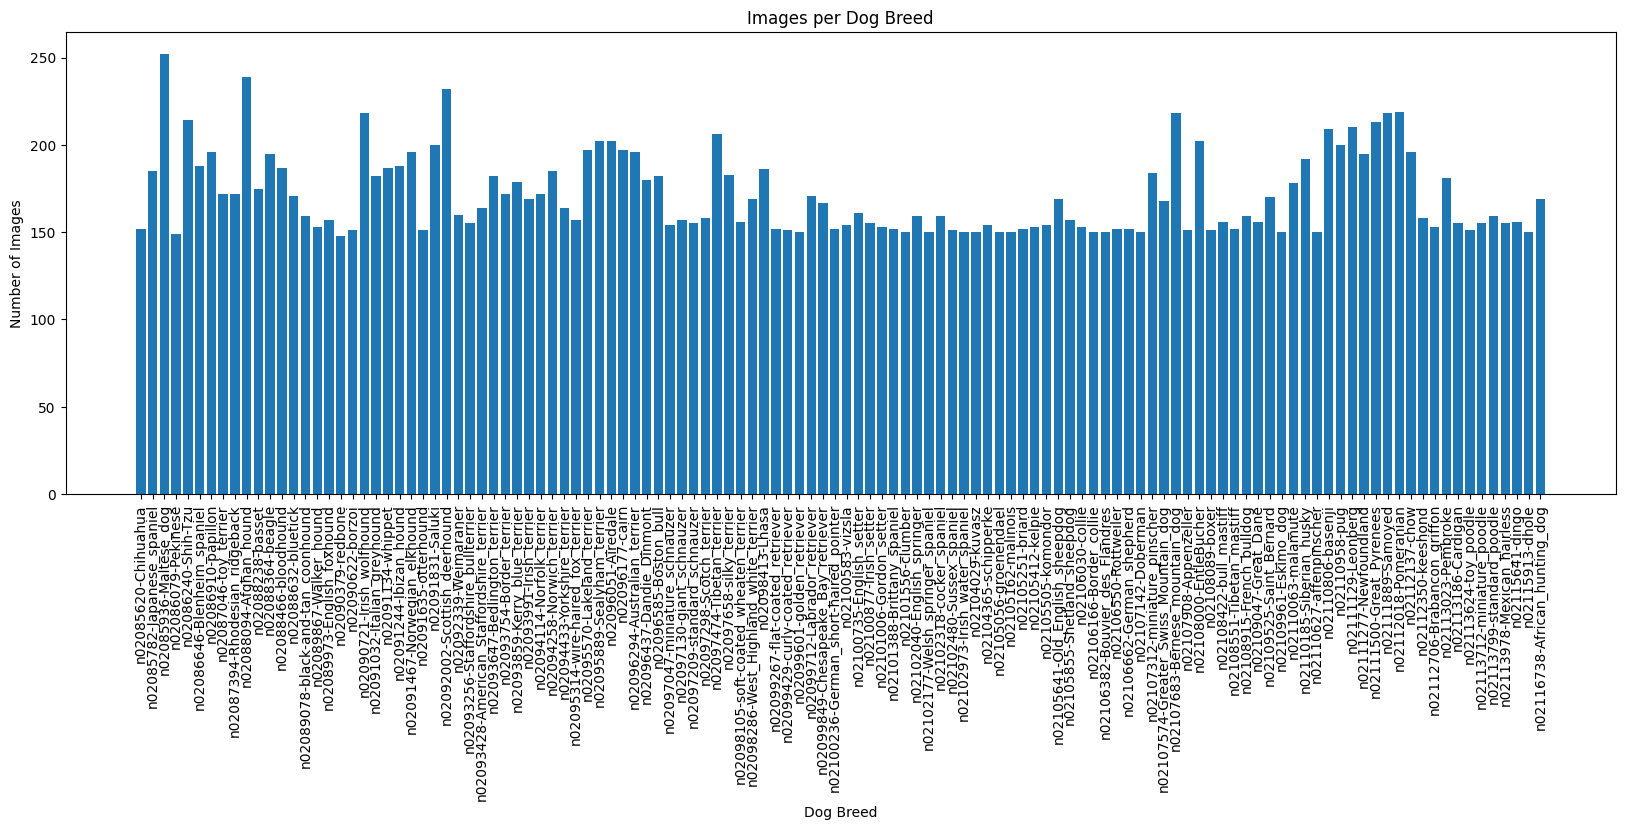

In [10]:
plt.figure(figsize=(20, 6))

plt.bar(
    class_counts_df["Breed"],
    class_counts_df["Image_Count"]
)

plt.xticks(rotation=90)
plt.xlabel("Dog Breed")
plt.ylabel("Number of Images")
plt.title("Images per Dog Breed")

plt.show()

**Observation:** The bar chart shows all 120 breeds sitting in a relatively narrow band (roughly 148–252 images each), with no breed being a severe outlier. This is close enough to balanced that plain accuracy is a reasonable primary metric, and no class-weighting or resampling strategy is strictly required.


### 1.6 Visual Sanity Check — Random Sample Images

Before building any pipeline around the file paths, it helps to actually *look* at a random sample of images from random breeds. This confirms that the files are valid photographs of dogs (not placeholder images, icons, or corrupted thumbnails) and gives a first visual impression of the image quality and framing variation in the dataset.


In [11]:
import random
from PIL import Image

plt.figure(figsize=(15, 10))

for i in range(12):
    breed = random.choice(classes)
    breed_path = os.path.join(dataset_dir, breed)

    images = [
        f for f in os.listdir(breed_path)
        if f.lower().endswith(image_extensions)
    ]

    image_name = random.choice(images)
    image_path = os.path.join(breed_path, image_name)

    image = Image.open(image_path)

    plt.subplot(3, 4, i + 1)
    plt.imshow(image)
    plt.title(breed)
    plt.axis("off")

plt.tight_layout()
plt.show()

Output hidden; open in https://colab.research.google.com to view.

### 1.7 Image Dimension Analysis

Images collected from different sources typically come in inconsistent resolutions and aspect ratios. This cell samples up to 20 images per class, reads their width and height, and computes summary statistics. The result directly informs the target input size chosen for the CNN — all images will need to be resized to a single fixed shape before they can be batched and fed to the network.


In [12]:
sizes = []

for cls in classes:
    class_path = os.path.join(dataset_dir, cls)

    images = [
        f for f in os.listdir(class_path)
        if f.lower().endswith(image_extensions)
    ]

    for image_name in images[:20]:
        image_path = os.path.join(class_path, image_name)

        try:
            with Image.open(image_path) as img:
                sizes.append(img.size)
        except:
            pass

sizes_df = pd.DataFrame(sizes, columns=["Width", "Height"])

sizes_df.describe()

,Width,Height
count,2400.00000,2400.000000
mean,444.12750,385.046250
std,138.80577,117.724064
min,112.00000,120.000000
25%,360.00000,333.000000
50%,500.00000,375.000000
75%,500.00000,445.250000
max,2272.00000,1704.000000


**Observation:** Image dimensions vary substantially — width ranges from **112 to 2272 px** and height from **120 to 1704 px**, with a mean of roughly **444×385 px** and a median around **500×375 px**. This confirms images cannot be fed into a CNN in their original, inconsistent sizes and must be resized to a single fixed shape (224×224, matching MobileNetV2's expected input) as part of the loading pipeline.


### 1.8 Build a Master Image–Label DataFrame

Now that the class folders are validated, this cell walks every image file in every breed folder and builds a single tidy DataFrame with one row per image: its full file path and its breed label (as a string). This flat table is the structure the rest of the pipeline (label encoding, train/val/test splitting, `tf.data` construction) is built on top of, instead of repeatedly re-scanning the filesystem.


In [13]:
import os
import pandas as pd

image_extensions = (".jpg", ".jpeg", ".png", ".bmp", ".webp")

data = []

for cls in classes:
    class_path = os.path.join(dataset_dir, cls)

    for file in os.listdir(class_path):

        if file.lower().endswith(image_extensions):

            image_path = os.path.join(class_path, file)

            data.append({
                "image_path": image_path,
                "breed": cls
            })

df = pd.DataFrame(data)

print("Total images:", len(df))
print("Total classes:", df["breed"].nunique())

df.head()

Total images: 20580
Total classes: 120


,image_path,breed
0,/content/dog_breed_dataset/Dogs class/n0208562...,n02085620-Chihuahua
1,/content/dog_breed_dataset/Dogs class/n0208562...,n02085620-Chihuahua
2,/content/dog_breed_dataset/Dogs class/n0208562...,n02085620-Chihuahua
3,/content/dog_breed_dataset/Dogs class/n0208562...,n02085620-Chihuahua
4,/content/dog_breed_dataset/Dogs class/n0208562...,n02085620-Chihuahua


### 2.1 Encode Breed Names as Integer Labels

Keras' `sparse_categorical_crossentropy` loss expects integer class labels, not string breed names. This cell creates a `class_to_index` mapping (breed name → integer 0–119) from the sorted, unique breed names, plus the reverse `index_to_class` mapping used later to translate predictions back into human-readable breed names.


In [14]:
classes = sorted(df["breed"].unique())

class_to_index = {
    breed: index
    for index, breed in enumerate(classes)
}

index_to_class = {
    index: breed
    for breed, index in class_to_index.items()
}

### 2.2 Verify the Label Mapping

A quick check that the mapping covers all 120 classes and that the first few index → breed pairs look correct, before this mapping is applied to the entire DataFrame.


In [15]:
print("Number of classes:", len(classes))

print("\nFirst 10 mappings:")
for i in range(10):
    print(i, "→", index_to_class[i])

Number of classes: 120

First 10 mappings:
0 → n02085620-Chihuahua
1 → n02085782-Japanese_spaniel
2 → n02085936-Maltese_dog
3 → n02086079-Pekinese
4 → n02086240-Shih-Tzu
5 → n02086646-Blenheim_spaniel
6 → n02086910-papillon
7 → n02087046-toy_terrier
8 → n02087394-Rhodesian_ridgeback
9 → n02088094-Afghan_hound


In [16]:
df["label"] = df["breed"].map(class_to_index)

In [17]:
df.head()

,image_path,breed,label
0,/content/dog_breed_dataset/Dogs class/n0208562...,n02085620-Chihuahua,0
1,/content/dog_breed_dataset/Dogs class/n0208562...,n02085620-Chihuahua,0
2,/content/dog_breed_dataset/Dogs class/n0208562...,n02085620-Chihuahua,0
3,/content/dog_breed_dataset/Dogs class/n0208562...,n02085620-Chihuahua,0
4,/content/dog_breed_dataset/Dogs class/n0208562...,n02085620-Chihuahua,0


## 3. Train / Validation / Test Split

The full dataset is split into three disjoint sets:
- **Training set** — used to update model weights.
- **Validation set** — used during training to monitor generalization and trigger early stopping.
- **Test set** — held out completely until final evaluation, to give an unbiased estimate of real-world performance.

A **70 / 15 / 15** split is used, implemented as two sequential `train_test_split` calls (70% train, then the remaining 30% split evenly into validation and test). `stratify=df["label"]` is used in both calls so that each breed is represented proportionally in every split — important with 120 classes, since a non-stratified split risks leaving some breeds with very few (or zero) validation/test examples.


In [18]:
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["label"],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=42
)

In [19]:
print("Training:", len(train_df))
print("Validation:", len(val_df))
print("Testing:", len(test_df))

Training: 14406
Validation: 3087
Testing: 3087


**Observation:** The 70/15/15 stratified split produced **14,406** training images, **3,087** validation images, and **3,087** test images — matching the intended proportions of the full 20,580-image dataset.


### 3.1 Confirm No Classes Were Dropped by the Split

Since the split is stratified, this cell double-checks that all 120 breeds are still present in the training, validation, and test sets after splitting — a class silently disappearing from one of the splits would be an easy mistake to miss.


In [20]:
print("Train classes:", train_df["breed"].nunique())
print("Validation classes:", val_df["breed"].nunique())
print("Test classes:", test_df["breed"].nunique())

Train classes: 120
Validation classes: 120
Test classes: 120


In [21]:
train_df.head(10)

,image_path,breed,label
1842,/content/dog_breed_dataset/Dogs class/n0208809...,n02088094-Afghan_hound,9
18493,/content/dog_breed_dataset/Dogs class/n0211201...,n02112018-Pomeranian,107
7657,/content/dog_breed_dataset/Dogs class/n0209629...,n02096294-Australian_terrier,42
610,/content/dog_breed_dataset/Dogs class/n0208607...,n02086079-Pekinese,3
15928,/content/dog_breed_dataset/Dogs class/n0210855...,n02108551-Tibetan_mastiff,93
1940,/content/dog_breed_dataset/Dogs class/n0208823...,n02088238-basset,10
2626,/content/dog_breed_dataset/Dogs class/n0208863...,n02088632-bluetick,13
17529,/content/dog_breed_dataset/Dogs class/n0211095...,n02110958-pug,102
12781,/content/dog_breed_dataset/Dogs class/n0210505...,n02105056-groenendael,73
12969,/content/dog_breed_dataset/Dogs class/n0210525...,n02105251-briard,75


## 4. Building the `tf.data` Input Pipeline

Rather than loading all ~20,000 images into memory as NumPy arrays, this project uses TensorFlow's `tf.data.Dataset` API to build an efficient, on-the-fly loading pipeline: image file paths and labels are turned into a dataset, images are decoded and resized lazily as they are consumed, and the pipeline is shuffled, batched, and prefetched for GPU-efficient training.


In [22]:
SEED = 42
IMG_SIZE = (224, 224)
BATCH_SIZE = 16

In [23]:
train_dataset = tf.data.Dataset.from_tensor_slices(
    (
        train_df["image_path"].values,
        train_df["label"].values
    )
)

val_dataset = tf.data.Dataset.from_tensor_slices(
    (
        val_df["image_path"].values,
        val_df["label"].values
    )
)

test_dataset = tf.data.Dataset.from_tensor_slices(
    (
        test_df["image_path"].values,
        test_df["label"].values
    )
)


### 4.1 Image Loading & Decoding Function

`load_image` is the core preprocessing function mapped over every entry in the `tf.data.Dataset`. For each `(image_path, label)` pair it:
1. Reads the raw file bytes from disk.
2. Decodes the JPEG bytes into a 3-channel (RGB) tensor.
3. Resizes the image to the fixed `IMG_SIZE` (224×224) required by MobileNetV2.
4. Casts pixel values to `float32` (required before they are passed into the model's preprocessing layer).

Because this is applied via `.map()` with `num_parallel_calls=tf.data.AUTOTUNE`, images are decoded and resized in parallel on the CPU while the GPU is busy training on the previous batch.


In [24]:
def load_image(image_path, label):
    image = tf.io.read_file(image_path)

    image = tf.image.decode_jpeg(
        image,
        channels=3
    )

    image = tf.image.resize(
        image,
        IMG_SIZE
    )

    image = tf.cast(
        image,
        tf.float32

    )

    return image, label


In [25]:
train_dataset = train_dataset.map(
    load_image,
    num_parallel_calls=tf.data.AUTOTUNE
)
1
val_dataset = val_dataset.map(
    load_image,
    num_parallel_calls=tf.data.AUTOTUNE
)

test_dataset = test_dataset.map(
    load_image,
    num_parallel_calls=tf.data.AUTOTUNE
)

### 4.2 Shuffling and Batching

The training set is shuffled (buffer size 1000) so the model doesn't see images in a fixed, breed-by-breed order every epoch — this is important because the raw file listing is naturally grouped by class. All three splits are then batched using `BATCH_SIZE = 16`. The validation and test sets are **not** shuffled, since their order doesn't affect evaluation and keeping it fixed makes debugging easier.


In [26]:
train_dataset = train_dataset.shuffle(
    1000,
    seed=SEED
).batch(BATCH_SIZE)

val_dataset = val_dataset.batch(BATCH_SIZE)

test_dataset = test_dataset.batch(BATCH_SIZE)

### 4.3 Sanity Check — Batch Shapes and Types

Before moving forward, it's worth confirming the pipeline is producing exactly what the model expects: a batch of shape `(BATCH_SIZE, 224, 224, 3)` in `float32`, paired with integer labels of shape `(BATCH_SIZE,)`.


In [27]:
for images, labels in train_dataset.take(1):
    print("Images shape:", images.shape)
    print("Labels shape:", labels.shape)
    print("Image dtype:", images.dtype)
    print("Labels dtype:", labels.dtype)

Images shape: (16, 224, 224, 3)
Labels shape: (16,)
Image dtype: <dtype: 'float32'>
Labels dtype: <dtype: 'int64'>


### 4.4 Visual Check — Inspecting a Training Batch

A quick visual look at a batch of images straight out of the pipeline confirms that decoding, resizing, and batching are all working correctly before any augmentation or modeling is layered on top.


In [37]:
import matplotlib.pyplot as plt

for images, labels in train_dataset.take(1):

    plt.figure(figsize=(12, 12))

    for i in range(16):
        plt.subplot(4, 4, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.axis("off")

    plt.tight_layout()
    plt.show()

Output hidden; open in https://colab.research.google.com to view.

### 4.5 Data Augmentation

To reduce overfitting and improve generalization, random augmentations are applied to training images: horizontal flips, small rotations (±10%), and zooming (±10%). This artificially increases the visual variety the model sees during training without needing any additional images. Augmentation is defined as a Keras layer here so it can later be embedded directly inside the model and applied automatically during training only (Keras disables augmentation layers automatically at inference time).


In [29]:
data_augmentation = tf.keras.Sequential([    #Augmentation increases the variety of training data, not necessarily the number of dataset samples.
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1)
])

### 4.6 Visual Check — Augmentation Effect

Applying the augmentation pipeline to a sample batch and plotting the result confirms the transformations look reasonable (dogs are still recognizable) and are not too aggressive to distort the images beyond usefulness.


In [36]:
import matplotlib.pyplot as plt

for images, labels in train_dataset.take(1):

    augmented_images = data_augmentation(images)

    plt.figure(figsize=(12, 12))

    for i in range(16):
        plt.subplot(4, 4, i + 1)
        plt.imshow(augmented_images[i].numpy().astype("uint8"))
        plt.axis("off")

    plt.tight_layout()
    plt.show()

Output hidden; open in https://colab.research.google.com to view.

## 5. Model Architecture — Transfer Learning with MobileNetV2

Training a CNN from scratch for a 120-class, ~20K-image fine-grained classification problem would require far more data and compute to reach good accuracy. Instead, this project uses **transfer learning**: a MobileNetV2 model pretrained on ImageNet (1.4M images, 1000 classes, many of which already include dog breeds) is used as a fixed feature extractor.

`base_model.trainable = False` freezes all of MobileNetV2's pretrained convolutional weights, so only the newly added classification head is trained. This is both faster and less prone to overfitting than training the full network from scratch, and MobileNetV2 specifically is chosen for its small size and speed, making the resulting model practical to deploy.


In [109]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

### 5.1 Classification Head

On top of the frozen MobileNetV2 backbone, a small trainable head is added:
- **`data_augmentation`** — applied first, on-the-fly, only during training.
- **`Lambda(mobilenet_v2.preprocess_input)`** — applies MobileNetV2's exact expected input normalization (scales pixels to the `[-1, 1]` range it was pretrained on).
- **`base_model`** — the frozen MobileNetV2 feature extractor.
- **`GlobalAveragePooling2D`** — collapses the backbone's spatial feature maps into a single feature vector per image, drastically reducing the number of parameters compared to flattening.
- **`Dense(256, activation="relu")`** — a trainable fully-connected layer that learns task-specific combinations of the extracted features.
- **`Dropout(0.3)`** — randomly disables 30% of neurons during training to further reduce overfitting.
- **`Dense(120, activation="softmax")`** — the output layer, producing a probability distribution over all 120 dog breeds.


In [110]:
mobilenet_model = tf.keras.Sequential([

    tf.keras.layers.Input(
        shape=(224, 224, 3)
    ),

    data_augmentation,

    tf.keras.layers.Lambda(
        tf.keras.applications.mobilenet_v2.preprocess_input
    ),

    base_model,

    tf.keras.layers.GlobalAveragePooling2D(),

    tf.keras.layers.Dense(
        256,
        activation="relu"
    ),

    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(
        120,
        activation="softmax"
    )
])
mobilenet_model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda_6 (Lambda)               │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_6      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 120)            │        30,840 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,616,760 (9.98 MB)

 Trainable params: 358,776 (1.37 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

### 5.2 Compiling the Model

The model is compiled with the **Adam** optimizer (learning rate 0.001), **sparse categorical cross-entropy** loss (appropriate since labels are integer-encoded rather than one-hot vectors), and **accuracy** as the tracked metric.


In [33]:
mobilenet_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="sparse_categorical_crossentropy",       #We use SparseCategoricalCrossentropy because your labels are integers
    metrics=["accuracy"]
)

### 5.3 Early Stopping Callback

`EarlyStopping` monitors validation loss and stops training if it fails to improve for **7 consecutive epochs** (`patience=7`), automatically restoring the model's weights from the epoch with the best validation loss (`restore_best_weights=True`). This protects against overfitting and removes the need to manually guess the "right" number of epochs.


In [34]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=7,
    restore_best_weights=True
)

## 6. Model Training

The model is trained for up to 30 epochs, with early stopping able to halt training sooner if validation loss stops improving.


In [38]:
history = mobilenet_model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=30,
    callbacks=[early_stopping]
)

Epoch 1/30
901/901 ━━━━━━━━━━━━━━━━━━━━ 63s 48ms/step - accuracy: 0.5280 - loss: 1.8481 - val_accuracy: 0.7820 - val_loss: 0.7126
Epoch 2/30
901/901 ━━━━━━━━━━━━━━━━━━━━ 81s 55ms/step - accuracy: 0.6651 - loss: 1.1457 - val_accuracy: 0.7911 - val_loss: 0.6583
Epoch 3/30
901/901 ━━━━━━━━━━━━━━━━━━━━ 42s 45ms/step - accuracy: 0.7003 - loss: 1.0073 - val_accuracy: 0.8040 - val_loss: 0.6581
Epoch 4/30
901/901 ━━━━━━━━━━━━━━━━━━━━ 42s 45ms/step - accuracy: 0.7137 - loss: 0.9595 - val_accuracy: 0.7995 - val_loss: 0.6582
Epoch 5/30
901/901 ━━━━━━━━━━━━━━━━━━━━ 86s 50ms/step - accuracy: 0.7295 - loss: 0.8969 - val_accuracy: 0.8037 - val_loss: 0.6814
Epoch 6/30
901/901 ━━━━━━━━━━━━━━━━━━━━ 78s 45ms/step - accuracy: 0.7339 - loss: 0.8740 - val_accuracy: 0.7953 - val_loss: 0.6716
Epoch 7/30
901/901 ━━━━━━━━━━━━━━━━━━━━ 82s 46ms/step - accuracy: 0.7539 - loss: 0.8152 - val_accuracy: 0.8030 - val_loss: 0.6797
Epoch 8/30
901/901 ━━━━━━━━━━━━━━━━━━━━ 81s 45ms/step - accuracy: 0.7587 - loss: 0.7989 - 

### 6.2 Training Observations

Training ran for **10 epochs** before early stopping triggered (best validation loss occurred at epoch 3, and training continued for the full 7-epoch patience window afterward without improving, as confirmed by the "Best epoch" check below).

Key trend from the logs:
- **Training accuracy** rose steadily throughout, from **52.8%** (epoch 1) to **77.3%** (epoch 10) — the model kept fitting the training data better every epoch.
- **Validation accuracy** climbed quickly in the first few epochs (78.2% → 80.4% by epoch 3) and then **plateaued around 79–80%** for the rest of training, without meaningful further improvement.
- **Validation loss** reached its minimum at **epoch 3 (0.6581)**, then drifted upward and became noisier in later epochs (up to 0.7521 at epoch 9) even as training loss kept falling — a classic sign that the frozen-backbone head had converged and further training was mildly overfitting rather than generalizing further.

This is exactly the pattern `EarlyStopping(monitor="val_loss", patience=7, restore_best_weights=True)` is designed to catch: it lets training continue for a while to make sure epoch 3 wasn't a lucky fluctuation, then restores the epoch-3 weights once it's clear later epochs aren't improving.


In [43]:

best_epoch = np.argmin(history.history["val_loss"]) + 1

print("Best epoch:", best_epoch)
print("Best validation loss:", history.history["val_loss"][best_epoch - 1])
print("Best validation accuracy:", history.history["val_accuracy"][best_epoch - 1])

Best epoch: 3
Best validation loss: 0.658115565776825
Best validation accuracy: 0.8040168285369873


## 6.1 Saving the Trained Model

The trained model (with the best weights restored by early stopping) is saved to disk in the native Keras format so it can be reloaded later for evaluation or deployment without retraining.


In [40]:
mobilenet_model.save("30_epoch_model.keras")

In [56]:
print(os.path.getsize("30_epoch_model.keras") / (1024 * 1024), "MB")

13.29520034790039 MB


**Observation:** The saved model is only **~13.3 MB**, a direct benefit of using the lightweight MobileNetV2 backbone with a frozen base — this keeps the model practical to deploy on mobile or edge environments, not just as a research artifact.


### 6.3 Training vs. Validation Accuracy Curve

Plotting accuracy across epochs for both the training and validation sets helps diagnose overfitting: if training accuracy keeps climbing while validation accuracy stalls or drops, the model is memorizing the training data rather than generalizing.


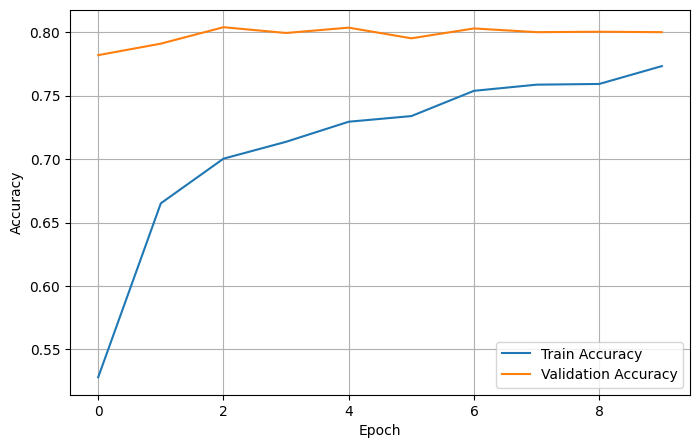

In [41]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()
plt.show()

### 6.4 Training vs. Validation Loss Curve

The loss curves tell the same story as the accuracy curves but are typically more sensitive to overfitting — validation loss beginning to rise while training loss keeps falling is the classic overfitting signature, and is exactly what `EarlyStopping(monitor="val_loss")` is watching for.


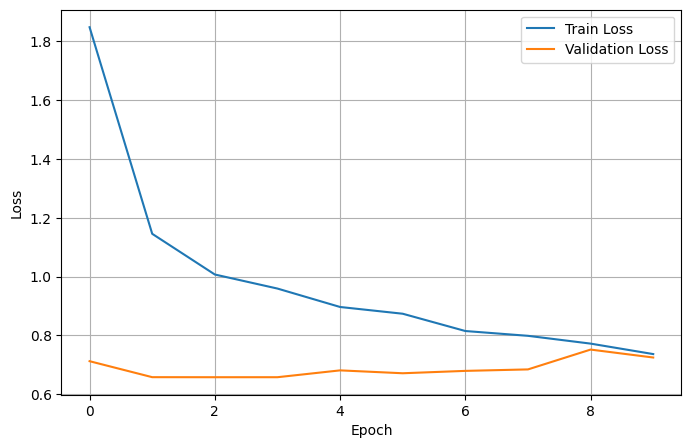

In [42]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid()
plt.show()

## 7. Final Evaluation on the Held-Out Test Set

Up to this point, the validation set has only been used to guide training decisions (early stopping). The **test set has not been touched at all** until now, so evaluating on it gives an unbiased measure of how the model would perform on genuinely unseen images.


In [45]:
test_loss, test_accuracy = mobilenet_model.evaluate(test_dataset)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

193/193 ━━━━━━━━━━━━━━━━━━━━ 8s 41ms/step - accuracy: 0.8024 - loss: 0.6409
Test Loss: 0.6409153938293457
Test Accuracy: 0.8023971319198608


**Observation:** The model reaches **80.24% accuracy** on the held-out test set (test loss 0.641), closely matching the **~80.4% validation accuracy** seen during training. The close agreement between validation and test performance indicates the validation set was a reliable proxy during training and the model generalizes consistently to unseen data, on a genuinely difficult 120-class fine-grained classification problem.


### 7.1 Generating Predictions Over the Test Set

To compute per-class metrics and a confusion matrix, predictions are generated for every batch in the test set and collected alongside their true labels into two flat NumPy arrays, `y_true` and `y_pred`.


In [47]:
y_true = []
y_pred = []

for images, labels in test_dataset:
    predictions = mobilenet_model.predict(images, verbose=0)

    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print("True labels shape:", y_true.shape)
print("Predicted labels shape:", y_pred.shape)

True labels shape: (3087,)
Predicted labels shape: (3087,)


### 7.2 Recovering Ordered Class Names

For readable reports (precision/recall per breed, confusion matrix axis labels), the integer labels need to be mapped back to breed name strings, in the same order as the integer encoding (0–119) used by the model.


In [49]:
class_names = (
    train_df.sort_values("label")
    .drop_duplicates("label")["breed"]
    .tolist()
)

print(len(class_names))
print(class_names)

120
['n02085620-Chihuahua', 'n02085782-Japanese_spaniel', 'n02085936-Maltese_dog', 'n02086079-Pekinese', 'n02086240-Shih-Tzu', 'n02086646-Blenheim_spaniel', 'n02086910-papillon', 'n02087046-toy_terrier', 'n02087394-Rhodesian_ridgeback', 'n02088094-Afghan_hound', 'n02088238-basset', 'n02088364-beagle', 'n02088466-bloodhound', 'n02088632-bluetick', 'n02089078-black-and-tan_coonhound', 'n02089867-Walker_hound', 'n02089973-English_foxhound', 'n02090379-redbone', 'n02090622-borzoi', 'n02090721-Irish_wolfhound', 'n02091032-Italian_greyhound', 'n02091134-whippet', 'n02091244-Ibizan_hound', 'n02091467-Norwegian_elkhound', 'n02091635-otterhound', 'n02091831-Saluki', 'n02092002-Scottish_deerhound', 'n02092339-Weimaraner', 'n02093256-Staffordshire_bullterrier', 'n02093428-American_Staffordshire_terrier', 'n02093647-Bedlington_terrier', 'n02093754-Border_terrier', 'n02093859-Kerry_blue_terrier', 'n02093991-Irish_terrier', 'n02094114-Norfolk_terrier', 'n02094258-Norwich_terrier', 'n02094433-Yorkshi

### 7.3 Per-Class Precision, Recall, and F1-Score

While overall test accuracy gives a single headline number, `classification_report` breaks performance down **per breed**, showing precision, recall, and F1-score for each of the 120 classes individually. This is essential for a fine-grained classification problem, where overall accuracy can mask specific breeds the model struggles with.


In [50]:
from sklearn.metrics import classification_report

report = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    zero_division=0
)

print(report)

                                          precision    recall  f1-score   support

                     n02085620-Chihuahua       0.89      0.70      0.78        23
              n02085782-Japanese_spaniel       1.00      0.79      0.88        28
                   n02085936-Maltese_dog       0.84      0.84      0.84        38
                      n02086079-Pekinese       0.90      0.86      0.88        22
                      n02086240-Shih-Tzu       0.79      0.81      0.80        32
              n02086646-Blenheim_spaniel       0.93      0.89      0.91        28
                      n02086910-papillon       0.83      0.97      0.89        30
                   n02087046-toy_terrier       0.72      0.69      0.71        26
           n02087394-Rhodesian_ridgeback       0.58      0.73      0.64        26
                  n02088094-Afghan_hound       0.94      0.94      0.94        36
                        n02088238-basset       0.71      0.96      0.82        26
               

**Observation:** The model's **weighted-average F1-score is 0.80** (precision 0.82, recall 0.80) and **macro-average F1 is 0.79** (precision 0.81, recall 0.80) — the closeness of the weighted and macro averages confirms performance is fairly consistent across breeds rather than being propped up by a few large classes.

A few breeds stand out at each extreme:
- **Near-perfect classes:** `Mexican_hairless` (precision 1.00, recall 1.00, F1 1.00), `African_hunting_dog` (F1 0.98), `clumber` (F1 0.98), `dhole` (F1 0.93) — visually distinctive breeds with little overlap with others.
- **Hardest classes:** `collie` (precision 0.40, recall 0.26, F1 0.32), `standard_schnauzer` (F1 0.21), `Eskimo_dog` (F1 0.22), `Appenzeller` (F1 0.30) — these are breeds with close visual relatives in the dataset (e.g., Border Collie, other schnauzer sizes, Siberian Husky, other Swiss mountain-dog breeds), which the confusion matrix below confirms directly.


## 8. Confusion Matrix — Where Does the Model Get Confused?

Overall accuracy hides *which* breeds are being confused with each other. A confusion matrix over all 120 classes makes those patterns visible: strong diagonal cells mean a breed is well recognized, while off-diagonal cells reveal which breed pairs the model consistently mixes up (often visually similar breeds).


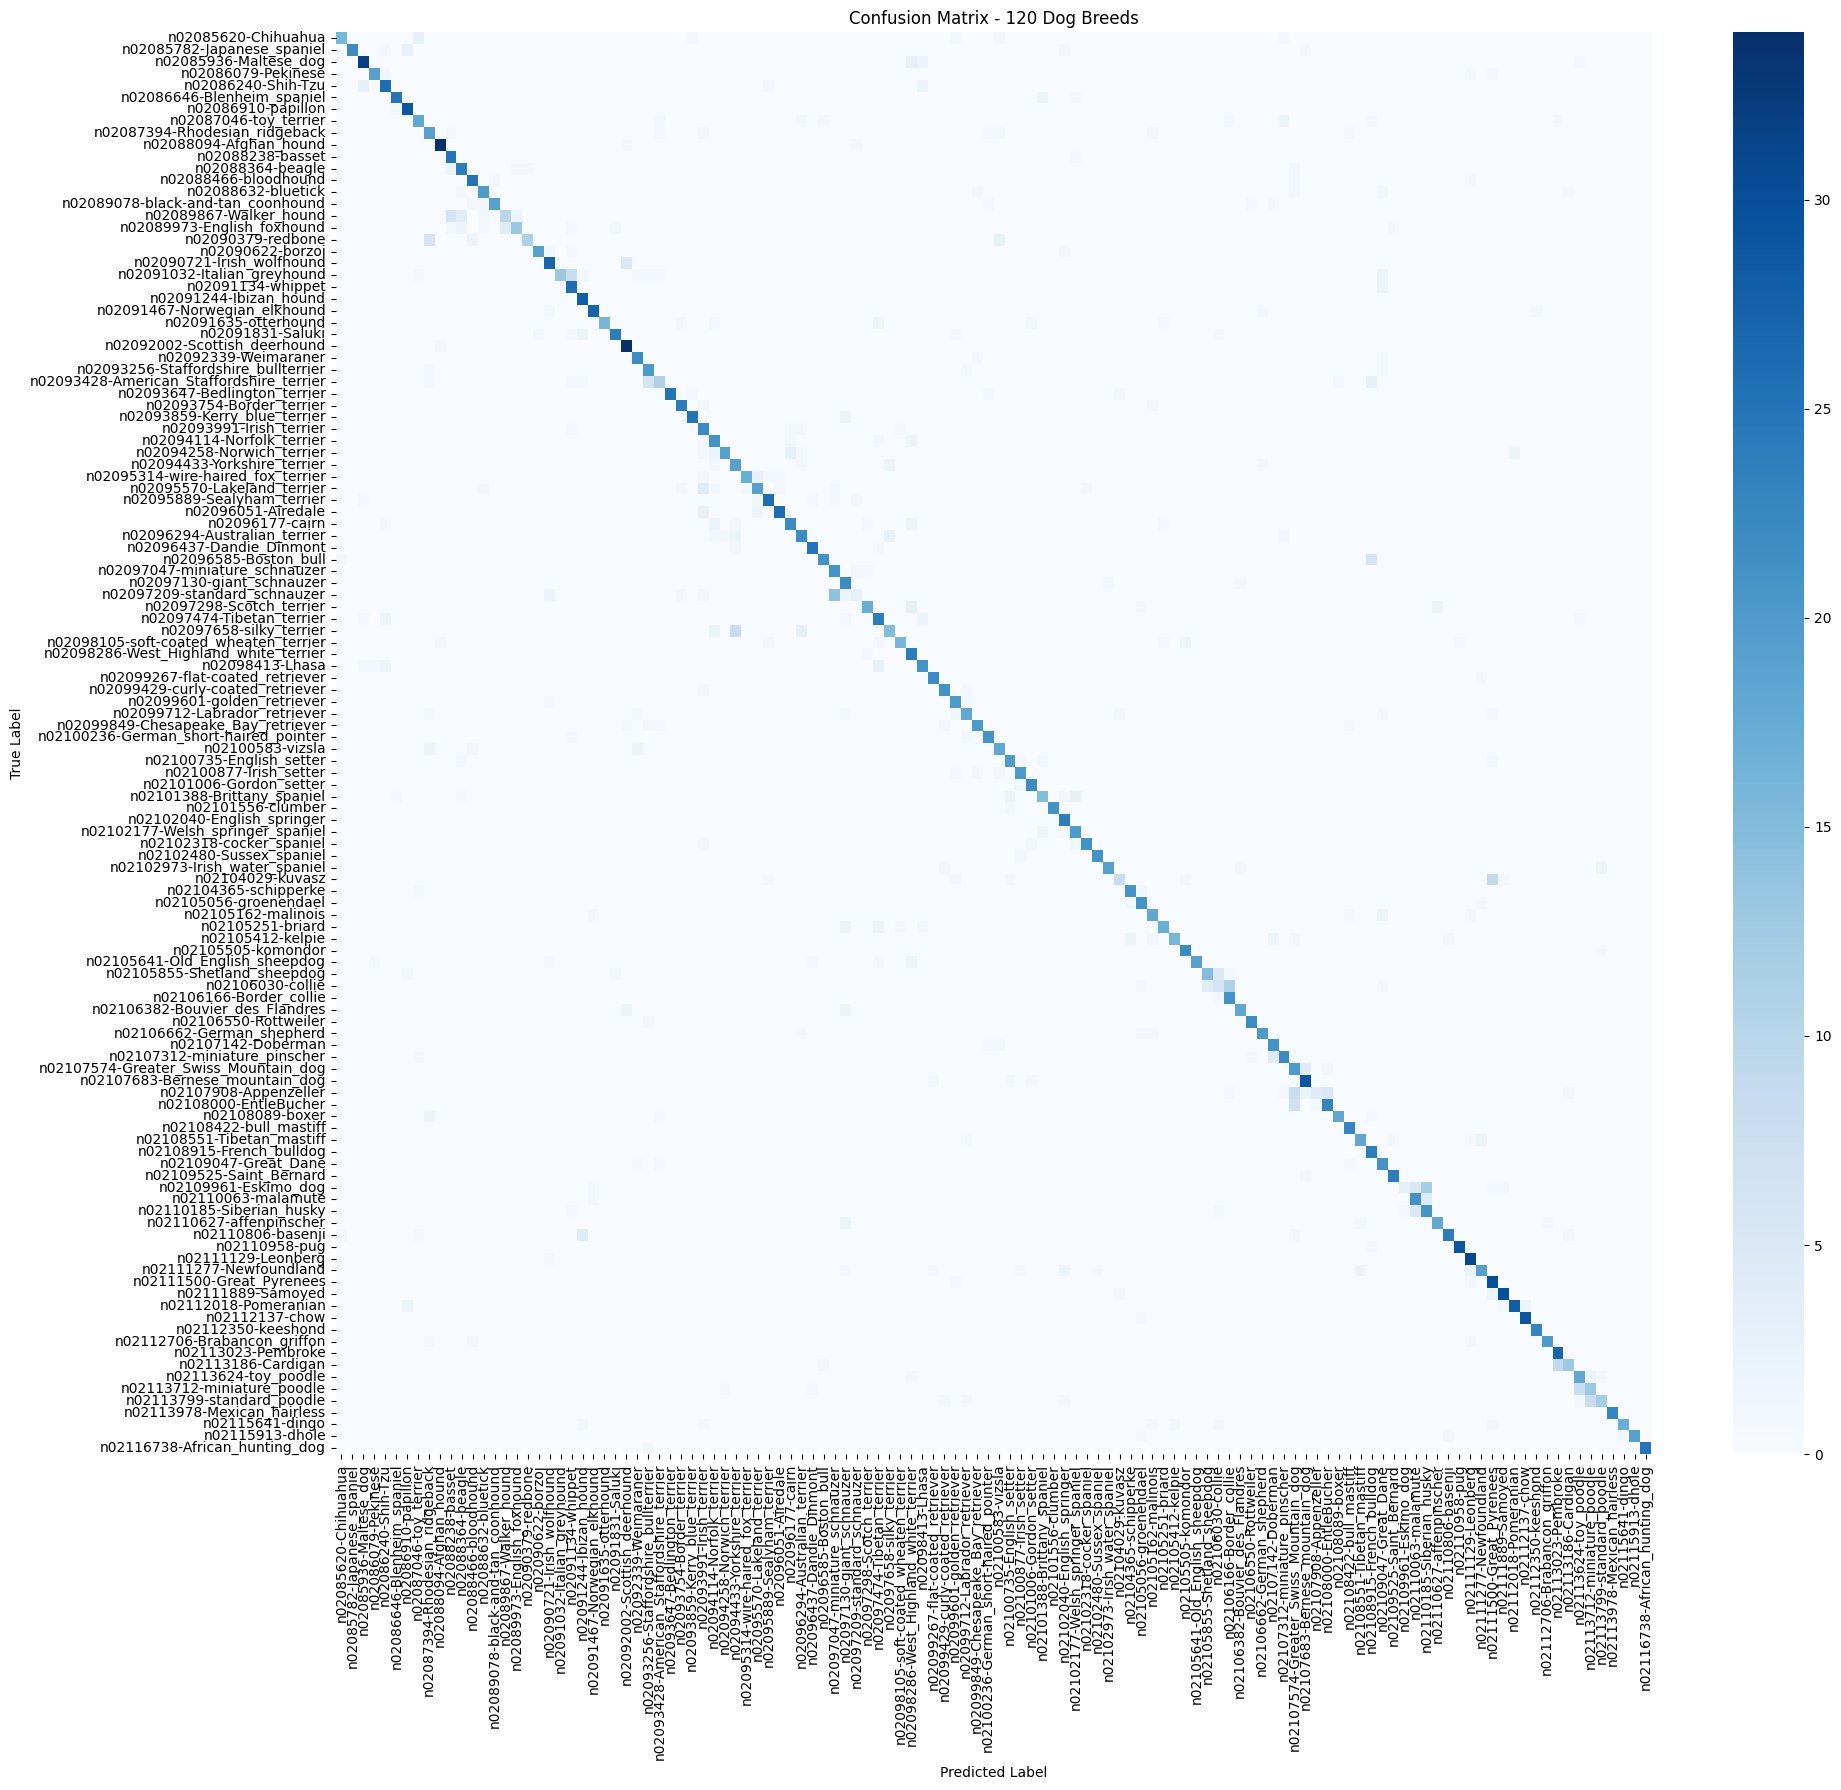

In [51]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(20, 18))
sns.heatmap(
    cm,
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - 120 Dog Breeds")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### 8.1 Top Confused Breed Pairs

With 120×120 = 14,400 cells, the confusion matrix heatmap alone is hard to read precisely. This cell zeroes out the diagonal (correct predictions) and ranks the remaining off-diagonal cells by count, surfacing the specific breed pairs the model confuses most often.


In [52]:
cm_no_diag = cm.copy()
np.fill_diagonal(cm_no_diag, 0)

indices = np.argsort(cm_no_diag.ravel())[::-1][:20]

for idx in indices:
    true_class, pred_class = np.unravel_index(idx, cm.shape)

    print(
        f"{class_names[true_class]} → {class_names[pred_class]} : "
        f"{cm[true_class, pred_class]} images"
    )

n02097209-standard_schnauzer → n02097047-miniature_schnauzer : 14 images
n02109961-Eskimo_dog → n02110185-Siberian_husky : 12 images
n02106030-collie → n02106166-Border_collie : 11 images
n02113186-Cardigan → n02113023-Pembroke : 9 images
n02104029-kuvasz → n02111500-Great_Pyrenees : 9 images
n02097658-silky_terrier → n02094433-Yorkshire_terrier : 8 images
n02107908-Appenzeller → n02107574-Greater_Swiss_Mountain_dog : 8 images
n02113799-standard_poodle → n02113712-miniature_poodle : 8 images
n02113712-miniature_poodle → n02113624-toy_poodle : 8 images
n02091032-Italian_greyhound → n02091134-whippet : 8 images
n02108000-EntleBucher → n02107574-Greater_Swiss_Mountain_dog : 7 images
n02096585-Boston_bull → n02108915-French_bulldog : 6 images
n02089867-Walker_hound → n02088238-basset : 6 images
n02090379-redbone → n02087394-Rhodesian_ridgeback : 6 images
n02093428-American_Staffordshire_terrier → n02093256-Staffordshire_bullterrier : 6 images
n02105855-Shetland_sheepdog → n02106030-collie 

**Observation:** The most confused pairs are consistently breeds that are visually very similar sub-types of the same dog family rather than random errors:
- `standard_schnauzer` → `miniature_schnauzer` (14 test images) — different sizes of the same breed.
- `Eskimo_dog` → `Siberian_husky` (12 images) — near-identical coat and build.
- `collie` → `Border_collie` (11 images) — closely related herding breeds.
- `Cardigan` → `Pembroke` (9 images) — the two Welsh Corgi varieties.
- `kuvasz` → `Great_Pyrenees` (9 images) — both large white livestock guardian breeds.
- `standard_poodle` → `miniature_poodle` and `miniature_poodle` → `toy_poodle` (8 images each) — the three poodle size variants confusing each other in a chain.

This pattern is reassuring from a model-quality standpoint: the errors are concentrated on genuinely hard, fine-grained distinctions (breed sub-types) rather than confusing unrelated dogs, which suggests the learned features are meaningful.


### 8.2 Collecting Misclassified Test Images

To go beyond the confusion matrix's numeric summary, this cell re-runs prediction over the test set while also keeping the raw image arrays, so specific misclassified images can be visually inspected below.


In [54]:
test_images = []
test_labels = []

for images, labels in test_dataset:
    test_images.extend(images.numpy())
    test_labels.extend(labels.numpy())

test_images = np.array(test_images)
test_labels = np.array(test_labels)

predictions = mobilenet_model.predict(test_images, verbose=0)
pred_labels = np.argmax(predictions, axis=1)

### 8.3 Visualizing Misclassified Examples

Looking directly at a sample of misclassified images, each labeled with its true breed and the model's (incorrect) prediction, helps sanity-check whether the errors are "reasonable" (visually similar breeds) or indicate a deeper problem in the pipeline.


In [55]:
wrong_indices = np.where(test_labels != pred_labels)[0]

print("Total wrong predictions:", len(wrong_indices))

plt.figure(figsize=(12, 12))

for i, idx in enumerate(wrong_indices[:16]):
    plt.subplot(4, 4, i + 1)

    plt.imshow(test_images[idx].astype("uint8"))

    true_name = class_names[test_labels[idx]]
    pred_name = class_names[pred_labels[idx]]

    plt.title(f"True: {true_name}\nPred: {pred_name}")
    plt.axis("off")

plt.tight_layout()
plt.show()

Output hidden; open in https://colab.research.google.com to view.

## 9. Inference on New, Unseen Images

Finally, the trained and saved model is used to make predictions on completely new images (not part of the original dataset) — this is the real-world usage scenario the model was built for, and validates that the full preprocessing → prediction pipeline works end-to-end outside of the training/evaluation loop.


### 9.1 End-to-End Prediction Function

`predict_dog_breed` packages the full inference pipeline into a single reusable function: it reads an image file from disk, decodes and resizes it to match the model's expected input, runs it through the trained model, converts the predicted class index back into a breed name, displays the image with its predicted breed and confidence, and returns both values. This is the function that would sit behind a deployed prediction API or app.


In [71]:
def predict_dog_breed(image_path):
    image = tf.io.read_file(image_path)
    image = tf.image.decode_image(               #converting into tensor
        image,
        channels=3,
        expand_animations=False
    )
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32)

    image_batch = tf.expand_dims(image, axis=0)  #expanding dimension(224,22,3) -> (1,224,224,3)

    predictions = mobilenet_model.predict(image_batch, verbose=0)

    predicted_index = np.argmax(predictions[0])     #index position
    confidence = predictions[0][predicted_index] * 100          #calculating percentage
    predicted_breed = class_names[predicted_index]         #coverting into breed names

    plt.figure(figsize=(5, 5))
    plt.imshow(image.numpy().astype("uint8"))
    plt.title(
        f"Breed: {predicted_breed}\n"
        f"Confidence: {confidence:.2f}%"
    )
    plt.axis("off")
    plt.show()

    return predicted_breed, confidence

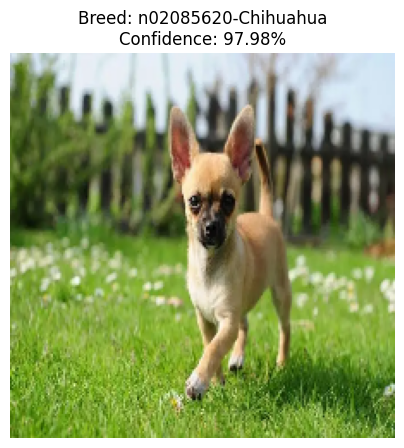

Predicted Breed: n02085620-Chihuahua
Confidence: 97.98%


In [72]:
image_path = "/content/images.webp"

breed, confidence = predict_dog_breed(image_path)

print("Predicted Breed:", breed)
print(f"Confidence: {confidence:.2f}%")

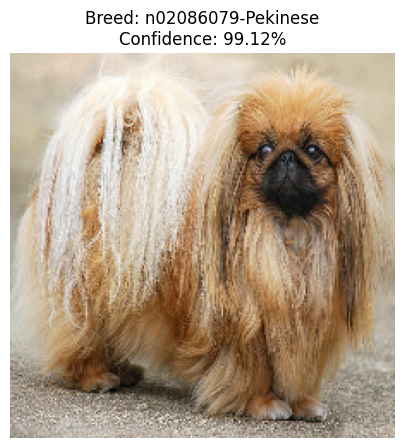

Predicted Breed: n02086079-Pekinese
Confidence: 99.12%


In [73]:
image_path = "/content/Pekinese.jpg"

breed, confidence = predict_dog_breed(image_path)

print("Predicted Breed:", breed)
print(f"Confidence: {confidence:.2f}%")

## 10. Conclusion

**Summary.** A MobileNetV2-based transfer learning model was trained to classify dog images into **120 breeds**, using a frozen ImageNet-pretrained backbone with a custom classification head (GlobalAveragePooling2D → Dense(256, ReLU) → Dropout(0.3) → Dense(120, Softmax)). Training used stratified 70/15/15 splits, on-the-fly `tf.data` loading with augmentation, and early stopping on validation loss.

**Results.**
| Metric | Value |
|---|---|
| Test Accuracy | **80.24%** |
| Test Loss | 0.641 |
| Best Validation Accuracy | 80.40% (epoch 3) |
| Weighted-avg F1 (test) | 0.80 |
| Macro-avg F1 (test) | 0.79 |
| Saved Model Size | ~13.3 MB |

**Key observations.**
- The model generalizes well: validation and test accuracy are nearly identical (~80%), with no evidence of severe overfitting thanks to the frozen backbone, dropout, augmentation, and early stopping.
- Nearly all misclassifications occur between closely related breed sub-types (different schnauzer/poodle/corgi sizes, husky vs. Eskimo dog, collie vs. Border collie) rather than unrelated breeds — the kind of error a human would plausibly make too.
- The two unseen test images used for standalone inference were both classified correctly with **high confidence (97.98% and 99.12%)**, validating that the end-to-end preprocessing-to-prediction pipeline works correctly outside of the training/evaluation loop.